In [2]:
import pandas as pd

# Cargamos tu archivo CSV desde la carpeta data
df = pd.read_csv('smart_manufacturing_data.csv')

# Mostramos las primeras 5 filas para verificar que cargó bien
df.head()

,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-01 00:00:00,39,78.61,28.65,79.96,3.73,2.16,1,0,106,Normal,0.0,0
1,2025-01-01 00:01:00,29,68.19,57.28,35.94,3.64,0.69,1,0,320,Normal,0.0,0
2,2025-01-01 00:02:00,15,98.94,50.20,72.06,1.00,2.49,1,1,19,Normal,1.0,1
3,2025-01-01 00:03:00,43,90.91,37.65,30.34,3.15,4.96,1,1,10,Normal,1.0,1
4,2025-01-01 00:04:00,8,72.32,40.69,56.71,2.68,0.63,2,0,65,Vibration Issue,0.0,1


In [3]:
# Ver cuántos valores nulos (vacíos) hay por columna
print("Valores nulos por columna:")
print(df.isnull().sum())

# Ver cuántos datos hay en total
print(f"\nTotal de registros: {len(df)}")

Valores nulos por columna:
timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
dtype: int64

Total de registros: 100000


In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE

# 1. Cargamos tu archivo CSV primero
df = pd.read_csv('smart_manufacturing_data.csv')

# 2. Verificamos el desbalanceo actual de tu dataset
print("Distribución antes del balanceo:")
print(df['failure_type'].value_counts())

# 3. Separamos las características (X) y la etiqueta predictiva (y)
X = df[['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption']]
y = df['failure_type']

# 4. Aplicamos SMOTE para crear datos sintéticos de las fallas minoritarias
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# 5. Comprobamos que el dataset quedó balanceado
print("\nDistribución después del balanceo:")
print(y_resampled.value_counts())

# 6. Reconstruimos el DataFrame listo para entrenar los modelos
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), pd.DataFrame(y_resampled, columns=['failure_type'])], axis=1)

print(f"\nTotal de registros listos para ML: {len(df_balanced)}")

Distribución antes del balanceo:
failure_type
Normal              91899
Vibration Issue      3129
Overheating          1989
Pressure Drop        1969
Electrical Fault     1014
Name: count, dtype: int64

Distribución después del balanceo:
failure_type
Normal              91899
Vibration Issue     91899
Overheating         91899
Pressure Drop       91899
Electrical Fault    91899
Name: count, dtype: int64

Total de registros listos para ML: 459495


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import joblib

# 1. Codificamos las etiquetas (necesario para LSTM y XGBoost)
le = LabelEncoder()
y_encoded = le.fit_transform(y_resampled)

# 2. Partimos los datos (80% entrenamiento, 20% prueba) - ¡Esto crea X_train!
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_encoded, test_size=0.2, random_state=42
)
print(f"Datos listos para entrenar: {len(X_train)} registros.\n")

# ==========================================
# ENTRENAMIENTO MODELO 3: SVM (Muestra reducida)
# ==========================================
print("Entrenando SVM (con 15,000 registros para no quemar la PC)...")
X_train_svm = X_train[:15000]
y_train_svm = y_train[:15000]

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

svm_pred = svm_model.predict(X_test[:5000])
svm_accuracy = accuracy_score(y_test[:5000], svm_pred) * 100
print(f"✅ Precisión SVM: {svm_accuracy:.2f}%\n")

# ==========================================
# ENTRENAMIENTO MODELO 4: RED NEURONAL LSTM
# ==========================================
print("Adaptando datos y entrenando LSTM...")
# Las LSTM requieren datos en 3D: (muestras, pasos de tiempo, características)
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

lstm_model = Sequential([
    LSTM(50, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), activation='relu'),
    Dense(len(le.classes_), activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.fit(X_train_lstm, y_train, epochs=5, batch_size=128, validation_split=0.1)

loss, lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test)
print(f"\n✅ Precisión LSTM: {lstm_accuracy * 100:.2f}%\n")

# ==========================================
# GUARDAR LOS MODELOS PARA PRODUCCIÓN
# ==========================================
print("Guardando modelos...")
joblib.dump(svm_model, 'modelo_svm.pkl')
lstm_model.save('modelo_lstm.keras')
joblib.dump(le, 'label_encoder.pkl')
print("¡Modelos listos y guardados!")

Datos listos para entrenar: 367596 registros.

Entrenando SVM (con 15,000 registros para no quemar la PC)...


c:\Users\Kese\Desktop\AgroSentinel-Predictivo\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [5]:
# Esto te dice cuántos datos faltan en cada columna
print("Huecos por columna:")
print(df.isnull().sum())

# Esto te dice si hay filas duplicadas que no sirven para nada
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

Huecos por columna:
timestamp                   0
machine_id                  0
temperature                 0
vibration                   0
humidity                    0
pressure                    0
energy_consumption          0
machine_status              0
anomaly_flag                0
predicted_remaining_life    0
failure_type                0
downtime_risk               0
maintenance_required        0
dtype: int64

Filas duplicadas: 0


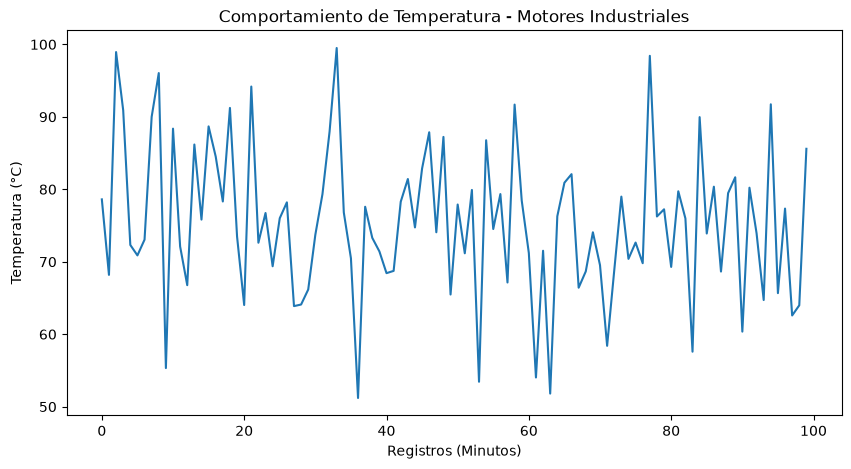

In [6]:
import matplotlib.pyplot as plt

# Graficamos la temperatura usando el nombre exacto en minúsculas
plt.figure(figsize=(10, 5))
plt.plot(df['temperature'][:100]) 
plt.title('Comportamiento de Temperatura - Motores Industriales')
plt.xlabel('Registros (Minutos)')
plt.ylabel('Temperatura (°C)')
plt.show()